# Zero-shot classification per layer — tabula-immune

Per ogni foundation model: metrica di classificazione zero-shot vs profondità relativa.

- **Asse x**: 0 % = primo blocco transformer, 100 % = ultimo blocco.
- **Linea continua**: media (5-fold CV per LogReg/kNN; bootstrap per Silhouette).
- **Banda ombreggiata** ±1 std: variabilità tra fold/bootstrap/seed Leiden.
- **Linea tratteggiata** (stesso colore): baseline PCA HVG del modello.

CSV in `data/classification_results/tabula-immune_<model>_classification_results.csv`.

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

DATASET     = "tabula-immune"
RESULTS_DIR = Path("../data/classification_results")
FIGURES_DIR = Path("../data")

# (metric_col, std_col, subplot_title)
METRICS = [
    ("Accuracy",         "Accuracy_std",        "LogReg — Accuracy"),
    ("F1_macro",         "F1_macro_std",        "LogReg — F1 macro"),
    ("kNN_Accuracy",     "kNN_Accuracy_std",    "kNN — Accuracy"),
    ("kNN_F1_macro",     "kNN_F1_macro_std",    "kNN — F1 macro"),
    ("Silhouette_Score", "Silhouette_Score_std","Silhouette Score"),
    ("ARI",              "ARI_std",             "ARI  (best Leiden)"),
    ("NMI",              "NMI_std",             "NMI  (best Leiden)"),
]

PALETTE = {
    "scfoundation": "#E64B35",
    "tahoe_1b":     "#4DBBD5",
    "scgpt":        "#00A087",
    "uce":          "#3C5488",
    "genecompass":  "#F39B7F",
    "cellfm":       "#8491B4",
}
LABELS = {
    "scfoundation": "scFoundation",
    "tahoe_1b":     "Tahoe-1B",
    "scgpt":        "scGPT",
    "uce":          "UCE",
    "genecompass":  "GeneCompass",
    "cellfm":       "CellFM",
}

In [2]:
def load_results(dataset, results_dir):
    pattern = re.compile(
        rf"^{re.escape(dataset)}_(.+?)_classification_results\.csv$"
    )
    out = {}
    for p in sorted(Path(results_dir).glob(
        f"{dataset}_*_classification_results.csv"
    )):
        m = pattern.match(p.name)
        if m:
            out[m.group(1)] = pd.read_csv(p)
    return out


dfs = load_results(DATASET, RESULTS_DIR)

if dfs:
    print(f"Loaded {len(dfs)} model(s): {list(dfs.keys())}")
    for model, df in dfs.items():
        n_layers = df["Layer"].str.match(r"X_layer_\d+").sum()
        std_cols  = [c for c in df.columns if c.endswith("_std")]
        print(f"  {model:20s}  {n_layers} layers  std_cols={std_cols}")
else:
    print(
        f"No CSVs found for '{DATASET}' in {RESULTS_DIR}.\n"
        "Run: python scripts/run_experiment_grid.py "
        f"--filter dataset={DATASET} --filter task=classification"
    )

Loaded 2 model(s): ['chunk_0000', 'scfoundation']
  chunk_0000            24 layers  std_cols=['Accuracy_std', 'F1_macro_std', 'Precision_macro_std', 'Recall_macro_std', 'kNN_Accuracy_std', 'kNN_F1_macro_std', 'Silhouette_Score_std', 'ARI_std', 'NMI_std']
  scfoundation          7 layers  std_cols=['Accuracy_std', 'F1_macro_std', 'Precision_macro_std', 'Recall_macro_std', 'kNN_Accuracy_std', 'kNN_F1_macro_std', 'Silhouette_Score_std', 'ARI_std', 'NMI_std']


In [3]:
def add_relative_depth(df):
    df = df.copy()
    def _parse_idx(s):
        m = re.match(r"X_layer_(\d+)", str(s))
        return int(m.group(1)) if m else np.nan
    df["layer_idx"] = df["Layer"].map(_parse_idx)
    max_idx = df["layer_idx"].dropna().max()
    df["relative_depth"] = df["layer_idx"] / max_idx * 100
    return df, int(max_idx) + 1


data = {}
for model, df in dfs.items():
    prepared, n_layers = add_relative_depth(df)
    data[model] = {"df": prepared, "n_layers": n_layers}

print(f"{'Model':20s}  {'n_layers':>8s}")
print("-" * 32)
for model, info in sorted(data.items()):
    print(f"{LABELS.get(model, model):20s}  {info['n_layers']:>8d}")

Model                 n_layers
--------------------------------
chunk_0000                  24
scFoundation                 7


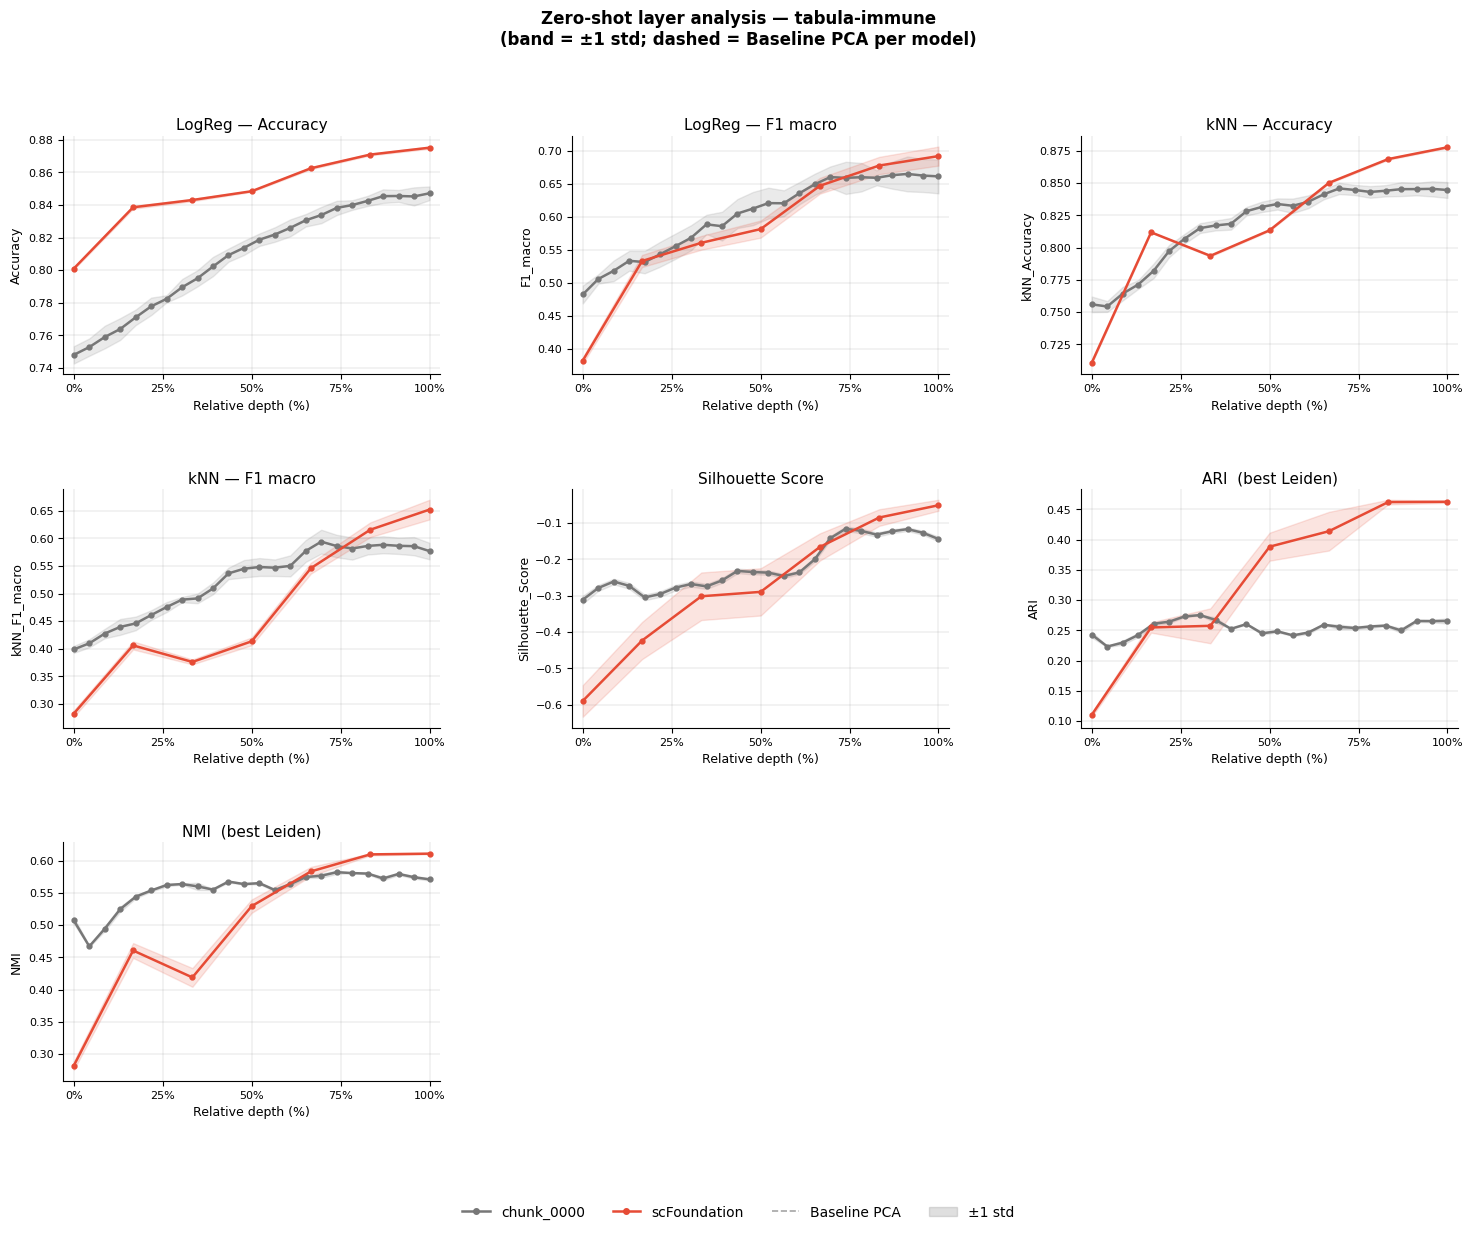

Saved → ../data/tabula-immune_classification_layers.pdf


In [4]:
if not data:
    print("No data to plot.")
else:
    NCOLS = 3
    NROWS = -(-len(METRICS) // NCOLS)

    fig, axes = plt.subplots(NROWS, NCOLS,
                             figsize=(6 * NCOLS, 4.2 * NROWS))
    fig.subplots_adjust(hspace=0.48, wspace=0.35, bottom=0.13)
    axes_flat = axes.flatten()

    for ax_i, (col, std_col, title) in enumerate(METRICS):
        ax = axes_flat[ax_i]

        for model_tag, info in data.items():
            df  = info["df"]
            clr = PALETTE.get(model_tag, "#777777")

            layer_rows = df.dropna(subset=["layer_idx"]).sort_values("layer_idx")
            if col in df.columns and not layer_rows.empty:
                x = layer_rows["relative_depth"]
                y = layer_rows[col]
                ax.plot(x, y, color=clr, marker="o",
                        markersize=3.5, linewidth=1.8, zorder=3)
                if std_col in layer_rows.columns:
                    s = layer_rows[std_col]
                    ax.fill_between(x, y - s, y + s,
                                   color=clr, alpha=0.15, zorder=2)

            brow = df[df["Layer"] == "Baseline_PCA"]
            if not brow.empty and col in brow.columns:
                ax.axhline(float(brow[col].values[0]),
                           color=clr, linestyle="--",
                           linewidth=1.2, alpha=0.65, zorder=2)

        ax.set_title(title, fontsize=11, pad=4)
        ax.set_xlabel("Relative depth (%)", fontsize=9)
        ax.set_ylabel(col, fontsize=9)
        ax.set_xlim(-3, 103)
        ax.xaxis.set_major_locator(plt.MultipleLocator(25))
        ax.xaxis.set_major_formatter(
            plt.FuncFormatter(lambda v, _: f"{int(v)}%"))
        ax.tick_params(labelsize=8)
        ax.grid(True, linewidth=0.35, color="gray", alpha=0.4)
        ax.spines[["top", "right"]].set_visible(False)

    for ax in axes_flat[len(METRICS):]:
        ax.set_visible(False)

    handles = []
    for model_tag in sorted(data.keys()):
        clr   = PALETTE.get(model_tag, "#777777")
        label = LABELS.get(model_tag, model_tag)
        handles.append(mlines.Line2D(
            [], [], color=clr, marker="o",
            markersize=4, linewidth=1.8, label=label))
    handles.append(mlines.Line2D(
        [], [], color="gray", linestyle="--",
        linewidth=1.2, alpha=0.7, label="Baseline PCA"))
    handles.append(mpatches.Patch(
        color="gray", alpha=0.25, label="±1 std"))

    fig.legend(handles, [h.get_label() for h in handles],
               loc="lower center", ncol=min(len(handles), 6),
               bbox_to_anchor=(0.5, 0.01), frameon=False, fontsize=10)

    fig.suptitle(
        f"Zero-shot layer analysis — {DATASET}\n"
        "(band = ±1 std; dashed = Baseline PCA per model)",
        fontsize=12, fontweight="bold")

    out_pdf = FIGURES_DIR / f"{DATASET}_classification_layers.pdf"
    plt.savefig(out_pdf, bbox_inches="tight")
    plt.show()
    print(f"Saved → {out_pdf}")

In [5]:
# Last-layer and best-layer summary table
if data:
    rows = []
    for model_tag, info in sorted(data.items()):
        df = info["df"]
        layer_df = df.dropna(subset=["layer_idx"])
        last_layer = layer_df.loc[layer_df["layer_idx"].idxmax()]
        row = {"Model": LABELS.get(model_tag, model_tag)}
        for col, std_col, _ in METRICS:
            if col in last_layer.index:
                row[f"{col} (last)"] = round(float(last_layer[col]), 4)
            if std_col in last_layer.index:
                row[f"{col}_std (last)"] = round(float(last_layer[std_col]), 4)
            if col in layer_df.columns:
                best_val = layer_df[col].max()
                best_pct = float(
                    layer_df.loc[layer_df[col].idxmax(), "relative_depth"])
                row[f"{col} (best)"]        = round(best_val, 4)
                row[f"{col} (best_depth%)"] = round(best_pct, 1)
        rows.append(row)

    summary = pd.DataFrame(rows).set_index("Model")
    display(summary.T)

Model,chunk_0000,scFoundation
Accuracy (last),0.8471,0.8751
Accuracy_std (last),0.0042,0.0007
Accuracy (best),0.8471,0.8751
Accuracy (best_depth%),100.0000,100.0000
F1_macro (last),0.6618,0.6926
F1_macro_std (last),0.0258,0.0144
F1_macro (best),0.6655,0.6926
F1_macro (best_depth%),91.3000,100.0000
kNN_Accuracy (last),0.8446,0.8777
kNN_Accuracy_std (last),0.0061,0.0005
